# Problema 3 - Mediciones de tiempo
Medimos el tiempo de ejecución del resolvedor de laberintos por backtracking y lo contrastamos con una referencia cuadrática $O(n^2)$.

In [2]:
%pip install -q matplotlib seaborn scipy


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import sys
import random
import numpy as np
import scipy as sp
import seaborn as sns
from matplotlib import pyplot as plt

# Importamos modulos desde el directorio actual y su padre
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(current_dir)
sys.path.append(parent_dir)

# Importamos la función a probar
from problema_3 import resolver_laberinto
from util import time_algorithm

# Establecemos semillas para la reproducibilidad de los resultados
random.seed(12345)
np.random.seed(12345)
sns.set_theme(style="whitegrid")

## Generacion de datos para las mediciones y graficos
Para cada tamano de lado $n$, generamos un laberinto cuadrado de $n \times n$ con paredes aleatorias y un camino garantizado entre entrada y salida.

Luego medimos el tiempo promedio de resolver el laberinto desde `E` hasta `S` usando `time_algorithm`.

Finalmente, convertimos tiempos a milisegundos y ajustamos contra una referencia teorica cuadratica $O(n^2)$ en funcion del lado $n$.

In [37]:
def generar_laberinto_con_camino(filas: int, cols: int, prob_pared: float = 0.28):
    lab = [["X" for _ in range(cols)] for _ in range(filas)]

    for i in range(1, filas - 1):
        for j in range(1, cols - 1):
            lab[i][j] = "-"

    entrada = (1, 1)
    salida = (filas - 2, cols - 2)

    camino = {entrada}
    i, j = entrada
    while (i, j) != salida:
        if i == salida[0]:
            j += 1
        elif j == salida[1]:
            i += 1
        elif random.random() < 0.5:
            i += 1
        else:
            j += 1
        camino.add((i, j))

    for r in range(1, filas - 1):
        for c in range(1, cols - 1):
            if (r, c) in camino:
                continue
            if random.random() < prob_pared:
                lab[r][c] = "X"

    lab[entrada[0]][entrada[1]] = "E"
    lab[salida[0]][salida[1]] = "S"
    return lab, entrada, salida

def args_tiempo(n_lado: int):
    lab, entrada, salida = generar_laberinto_con_camino(int(n_lado), int(n_lado))
    return entrada, salida, lab

# Rango de medicion
x = np.linspace(15, 60, 20).astype(int)
print("rango:", x)

results_tiempo_s = time_algorithm(resolver_laberinto, x, args_tiempo)
results_tiempo = {int(n): t * 1000.0 for n, t in results_tiempo_s.items()}

print("Resultados (ms):")
for n, t in results_tiempo.items():
    print(f"Tiempo para n={n}: {t:.12g} ms")

rango: [15 17 19 22 24 26 29 31 33 36 38 41 43 45 48 50 52 55 57 60]
Resultados (ms):
Tiempo para n=15: 0.0704288482666 ms
Tiempo para n=17: 0.0781774520874 ms
Tiempo para n=19: 0.143766403198 ms
Tiempo para n=22: 0.274682044983 ms
Tiempo para n=24: 0.254440307617 ms
Tiempo para n=26: 0.392270088196 ms
Tiempo para n=29: 0.334715843201 ms
Tiempo para n=31: 0.29890537262 ms
Tiempo para n=33: 0.434374809265 ms
Tiempo para n=36: 0.472021102905 ms
Tiempo para n=38: 0.472235679626 ms
Tiempo para n=41: 0.875854492188 ms
Tiempo para n=43: 0.441479682922 ms
Tiempo para n=45: 0.72603225708 ms
Tiempo para n=48: 0.574231147766 ms
Tiempo para n=50: 1.00080966949 ms
Tiempo para n=52: 0.704598426819 ms
Tiempo para n=55: 1.24278068542 ms
Tiempo para n=57: 0.854253768921 ms
Tiempo para n=60: 1.2211561203 ms


c_1 = 0.000305006828711, c_2 = 0.0678703145247
Error cuadratico total: 0.372268721326


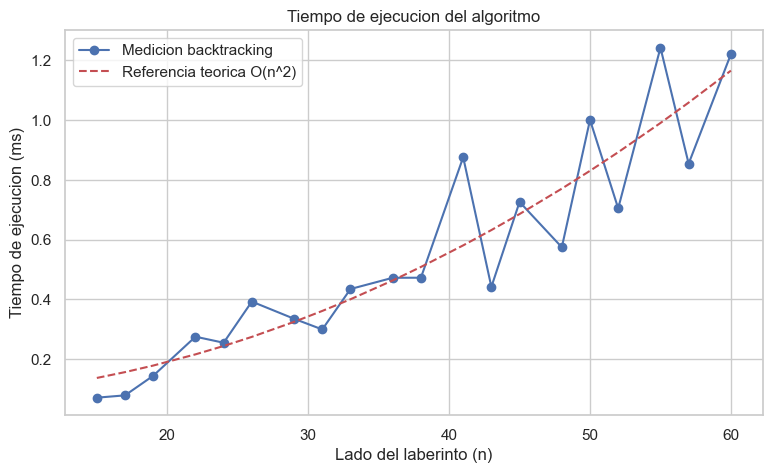

In [38]:
# scipy nos pide una función que recibe primero x y luego los parámetros a ajustar:
f_tiempo = lambda x, c1, c2: c1 * x**2 + c2
c, _ = sp.optimize.curve_fit(f_tiempo, x, [results_tiempo[n] for n in x])
r = np.sum((c[0] * x**2 + c[1] - [results_tiempo[n] for n in x])**2)

print(f"c_1 = {c[0]:.12g}, c_2 = {c[1]:.12g}")
print(f"Error cuadratico total: {r:.12g}")

ax: plt.Axes
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, [results_tiempo[n] for n in x], "o-", label="Medicion backtracking")
ax.plot(x, [c[0] * n**2 + c[1] for n in x], "r--", label="Referencia teorica O(n^2)")
ax.set_title("Tiempo de ejecucion del algoritmo")
ax.set_xlabel("Lado del laberinto (n)")
ax.set_ylabel("Tiempo de ejecucion (ms)")
ax.legend()

Text(0, 0.5, 'Error absoluto (ms)')

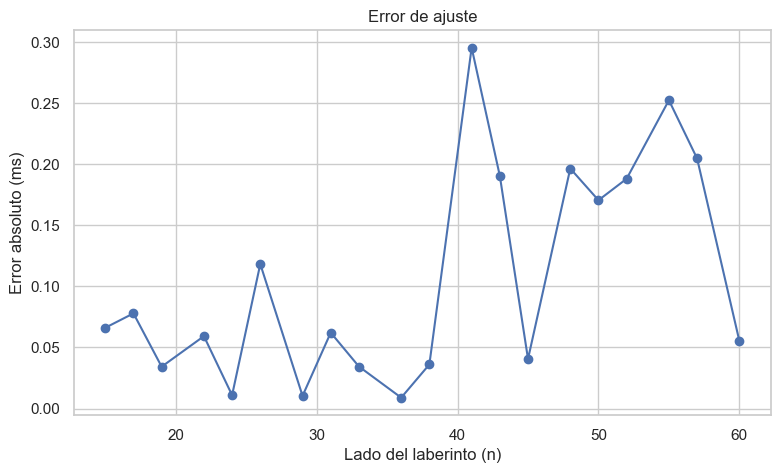

In [39]:
ax: plt.Axes
fig, ax = plt.subplots(figsize=(9, 5))
errors = [np.abs(c[0] * n**2 + c[1] - results_tiempo[n]) for n in x]
ax.plot(x, errors, "o-")
ax.set_title("Error de ajuste")
ax.set_xlabel("Lado del laberinto (n)")
ax.set_ylabel("Error absoluto (ms)")